# EDA - Dataset Distillato (Ministral 3B)
Analisi esplorativa del dataset distillato dal modello Ministral 3B.
Il dataset è composto da 7 file CSV (`pwc_distilled_0..6.csv`, ~70K righe) con 2 colonne: `description` e `Label` (10 classi).

Obiettivi:
1. Profilazione e analisi delle distribuzioni
2. Analisi dello sbilanciamento tra classi
3. Bilanciamento configurabile tramite subsampling

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Stile grafico
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = Path('../data/distilled')

## 1. Caricamento Dati

In [28]:
# Caricamento e concatenazione dei 7 file distillati
frames = []
for csv_path in sorted(DATA_DIR.glob('pwc_distilled_*.csv')):
    df_part = pd.read_csv(csv_path, low_memory=False)
    df_part['source_file'] = csv_path.stem  # traccia provenienza
    print(f'{csv_path.name}: {len(df_part):>8,} righe')
    frames.append(df_part)

df = pd.concat(frames, ignore_index=True)
del frames

print(f'\n=== DATASET DISTILLATO ===')
print(f'Righe totali:   {len(df):>12,}')
print(f'Colonne:        {list(df.columns)}')
print(f'Memoria (MB):   {df.memory_usage(deep=True).sum() / 1e6:>12,.1f}')
display(df.head())

pwc_distilled_0.csv:   10,000 righe
pwc_distilled_1.csv:    9,995 righe
pwc_distilled_2.csv:    9,994 righe
pwc_distilled_3.csv:   10,000 righe
pwc_distilled_4.csv:    9,999 righe
pwc_distilled_5.csv:   10,000 righe
pwc_distilled_6.csv:    9,989 righe

=== DATASET DISTILLATO ===
Righe totali:         69,977
Colonne:        ['description', 'Label', 'source_file']
Memoria (MB):           92.7


,description,Label,source_file
0,we build on the theory of ontology logs (ologs...,Research,pwc_distilled_0
1,the ability to detect and track the dynamic ob...,Research,pwc_distilled_0
2,strong demand for autonomous vehicles and the ...,Automotive & UVs,pwc_distilled_0
3,development of autonomous cyber system defense...,Research,pwc_distilled_0
4,this study presents a population-based evoluti...,Research,pwc_distilled_0


## 2. Profiling dei Dati

In [29]:
# Valori mancanti
print('Valori mancanti per colonna:')
print(df.isnull().sum())

print(f'\nTipi di dato:')
print(df.dtypes)

print(f'\nClassi uniche ({df["Label"].nunique()}):')
for label in sorted(df['Label'].unique()):
    print(f'  - {label}')

Valori mancanti per colonna:
description    0
Label          0
source_file    0
dtype: int64

Tipi di dato:
description    str
Label          str
source_file    str
dtype: object

Classi uniche (10):
  - Automotive & UVs
  - Enterprise
  - Environment
  - Fintech and Marketing
  - Generic use
  - Healthcare AI
  - Media & Entertainment
  - Research
  - Robotics and Industry
  - Virtual assistants


## 3. Distribuzione delle Classi

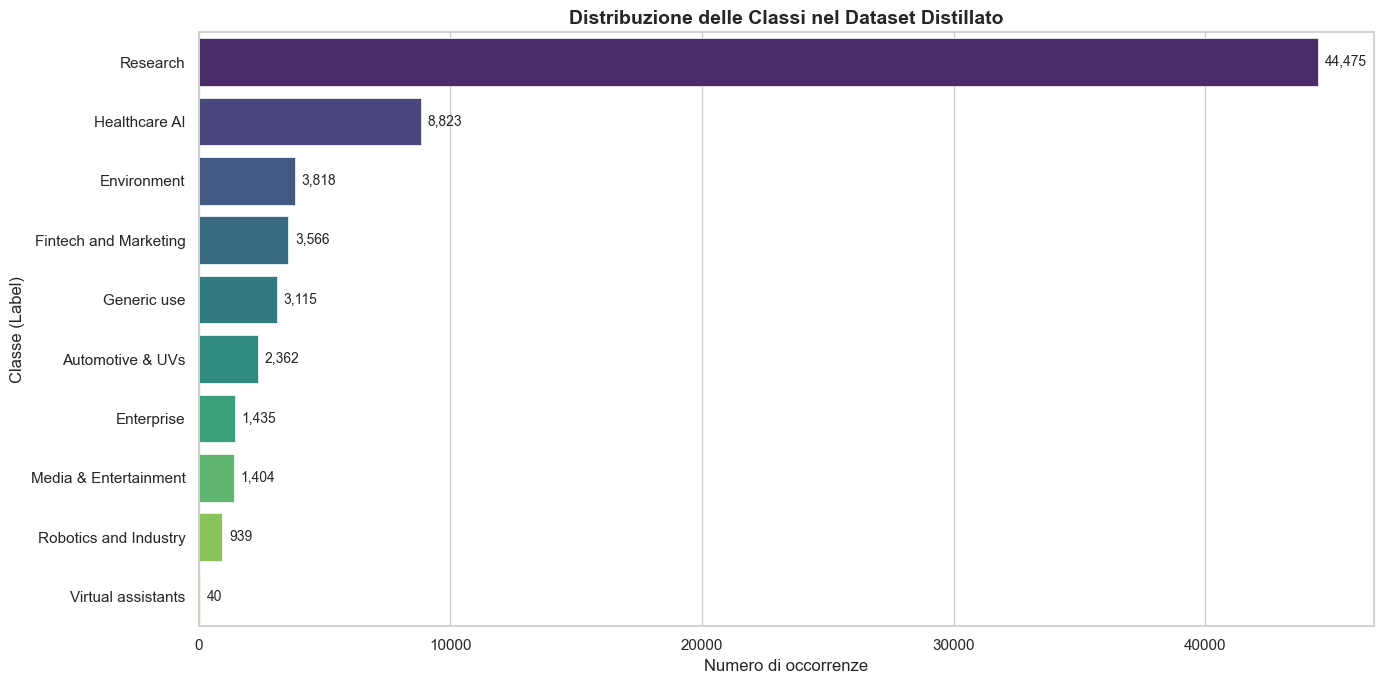

In [30]:
# Countplot orizzontale
label_order = df['Label'].value_counts().index

plt.figure(figsize=(14, 7))
ax = sns.countplot(data=df, y='Label', order=label_order,
                   palette='viridis', edgecolor='white', linewidth=0.5)

# Aggiungi conteggi sulle barre
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=5, fontsize=10)

ax.set_title('Distribuzione delle Classi nel Dataset Distillato', fontsize=14, fontweight='bold')
ax.set_xlabel('Numero di occorrenze')
ax.set_ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

In [31]:
# Tabella con conteggi assoluti e percentuali
label_stats = df['Label'].value_counts().to_frame('count')
label_stats['%'] = (label_stats['count'] / len(df) * 100).round(2)
label_stats['cumulative_%'] = label_stats['%'].cumsum().round(2)
display(label_stats)

,count,%,cumulative_%
Label,,,
Research,44475,63.56,63.56
Healthcare AI,8823,12.61,76.17
Environment,3818,5.46,81.63
Fintech and Marketing,3566,5.10,86.73
Generic use,3115,4.45,91.18
Automotive & UVs,2362,3.38,94.56
Enterprise,1435,2.05,96.61
Media & Entertainment,1404,2.01,98.62
Robotics and Industry,939,1.34,99.96


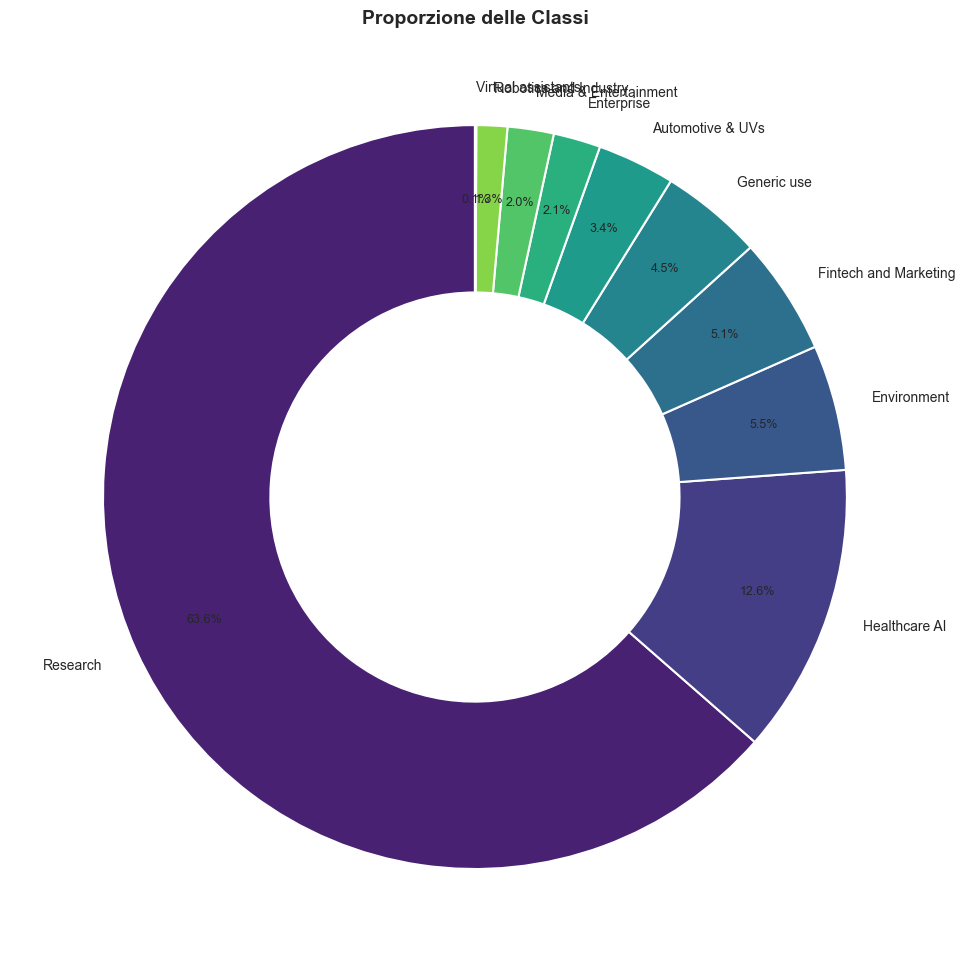

In [32]:
# Donut chart delle proporzioni
fig, ax = plt.subplots(figsize=(10, 10))
counts = df['Label'].value_counts()
colors = sns.color_palette('viridis', len(counts))

wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index, autopct='%1.1f%%',
    colors=colors, pctdistance=0.8, startangle=90,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=1.5)
)

for t in autotexts:
    t.set_fontsize(9)
for t in texts:
    t.set_fontsize(10)

ax.set_title('Proporzione delle Classi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Analisi Lunghezza Descrizioni

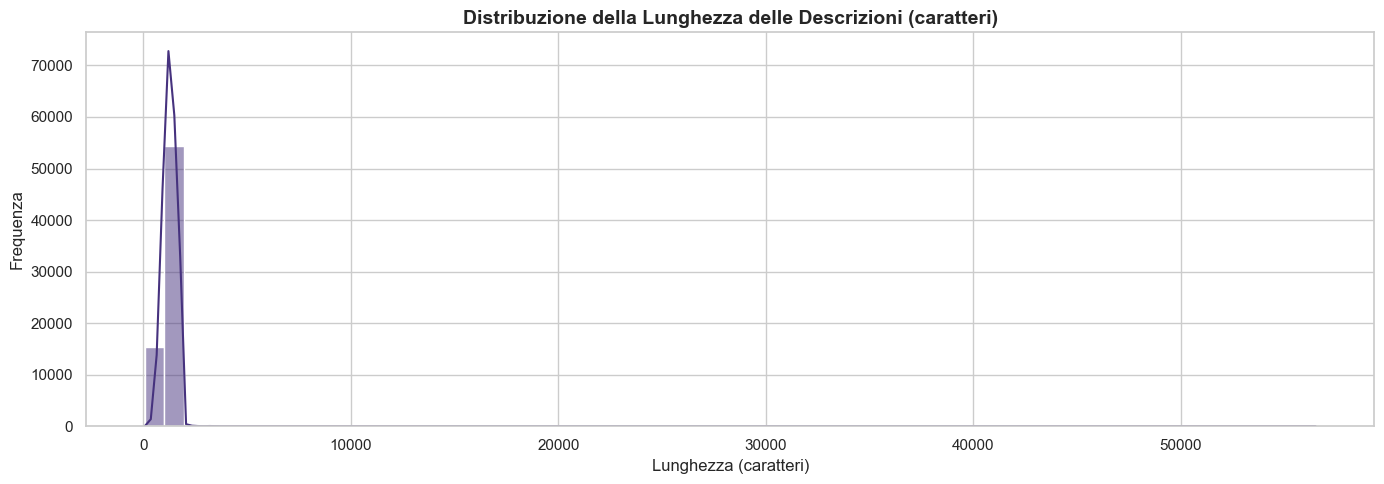


Statistiche globali:


,count,mean,std,min,25%,50%,75%,max
desc_length,69977.0,1274.94874,402.414855,68.0,1039.0,1269.0,1510.0,56487.0


In [33]:
df['desc_length'] = df['description'].astype(str).str.len()

# Distribuzione globale della lunghezza
plt.figure(figsize=(14, 5))
sns.histplot(df['desc_length'], bins=60, kde=True, color=sns.color_palette('viridis')[0])
plt.title('Distribuzione della Lunghezza delle Descrizioni (caratteri)', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Frequenza')
plt.tight_layout()
plt.show()

print(f'\nStatistiche globali:')
display(df['desc_length'].describe().to_frame('desc_length').T)

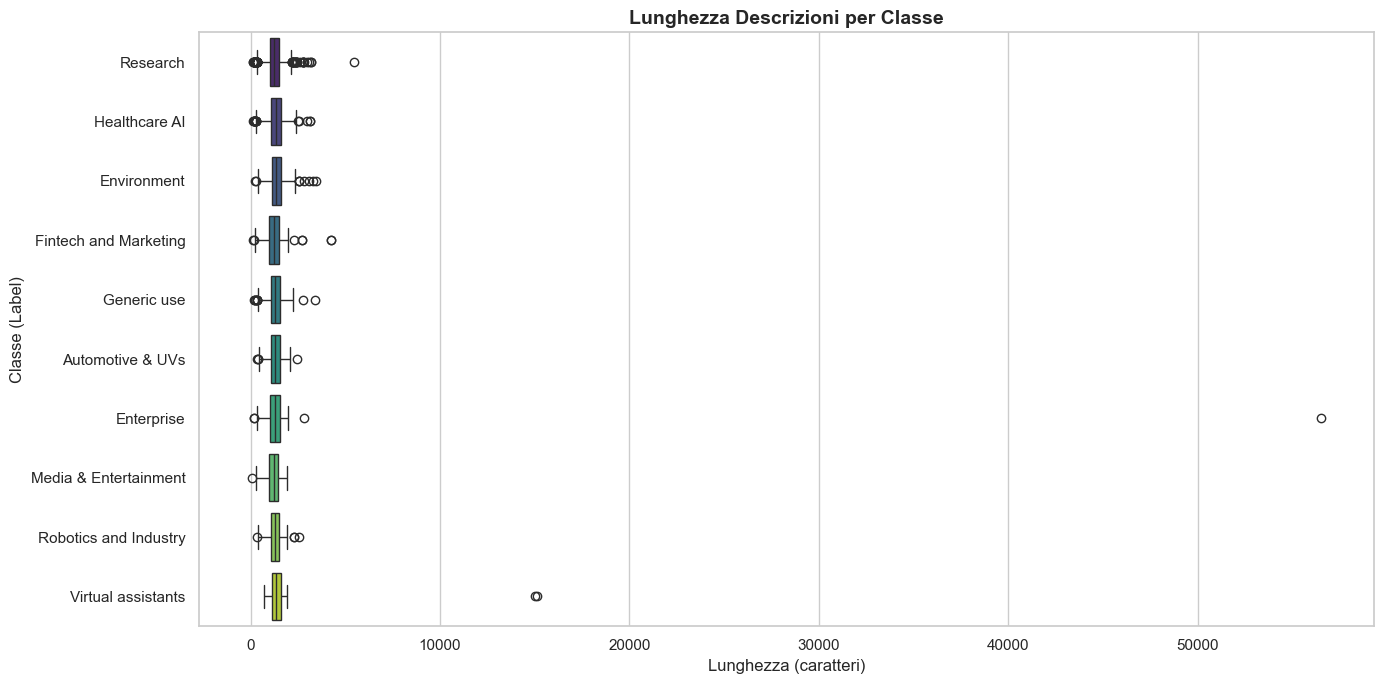


Statistiche lunghezza per classe:


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Research,44475.0,1255.949297,327.703704,138.0,1028.00,1251.0,1482.00,5448.0
Healthcare AI,8823.0,1336.512184,349.315403,116.0,1084.00,1341.0,1611.00,3156.0
Environment,3818.0,1344.713201,343.469238,225.0,1103.00,1349.0,1602.00,3427.0
Fintech and Marketing,3566.0,1247.739484,360.805091,122.0,994.25,1239.0,1500.75,4218.0
Generic use,3115.0,1295.490209,340.676754,177.0,1055.50,1298.0,1528.00,3393.0
Automotive & UVs,2362.0,1301.832345,318.899779,335.0,1080.25,1300.0,1530.00,2453.0
Enterprise,1435.0,1312.506620,1501.824921,191.0,1028.50,1269.0,1537.00,56487.0
Media & Entertainment,1404.0,1210.537749,339.516772,68.0,981.75,1213.0,1460.00,1931.0
Robotics and Industry,939.0,1287.610224,328.933207,328.0,1055.50,1290.0,1512.00,2568.0


In [34]:
# Boxplot lunghezza per classe
plt.figure(figsize=(14, 7))
sns.boxplot(data=df, x='desc_length', y='Label', order=label_order, palette='viridis')
plt.title('Lunghezza Descrizioni per Classe', fontsize=14, fontweight='bold')
plt.xlabel('Lunghezza (caratteri)')
plt.ylabel('Classe (Label)')
plt.tight_layout()
plt.show()

# Statistiche per classe
print('\nStatistiche lunghezza per classe:')
display(df.groupby('Label')['desc_length'].describe().sort_values('count', ascending=False))

## 5. Distribuzione per File Sorgente

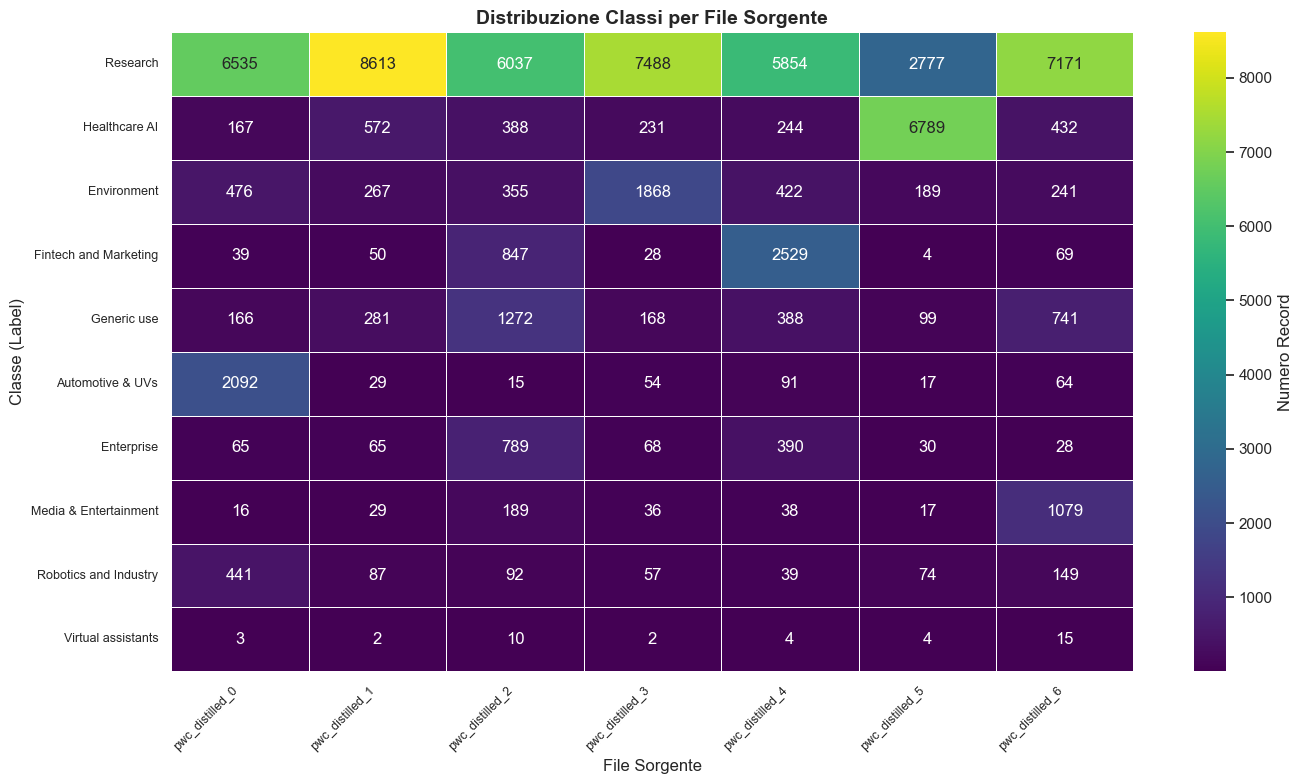

In [35]:
# Heatmap: classe x file sorgente
cross = pd.crosstab(df['Label'], df['source_file'])
cross = cross[sorted(cross.columns)]  # ordine file
cross = cross.loc[label_order]  # ordine per frequenza globale

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(cross, annot=True, fmt='d', cmap='viridis', linewidths=0.5,
            ax=ax, cbar_kws={'label': 'Numero Record'})
ax.set_title('Distribuzione Classi per File Sorgente', fontsize=14, fontweight='bold')
ax.set_xlabel('File Sorgente')
ax.set_ylabel('Classe (Label)')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 6. Imbalance Ratio e Metriche

Classe maggioritaria: Research (44,475)
Classe minoritaria:   Virtual assistants (40)
Imbalance Ratio:      1,111.9x

Entropia:             1.923 bit
Entropia max (uniforme): 3.322 bit
Entropia normalizzata:   0.579 (1.0 = perfettamente bilanciato)


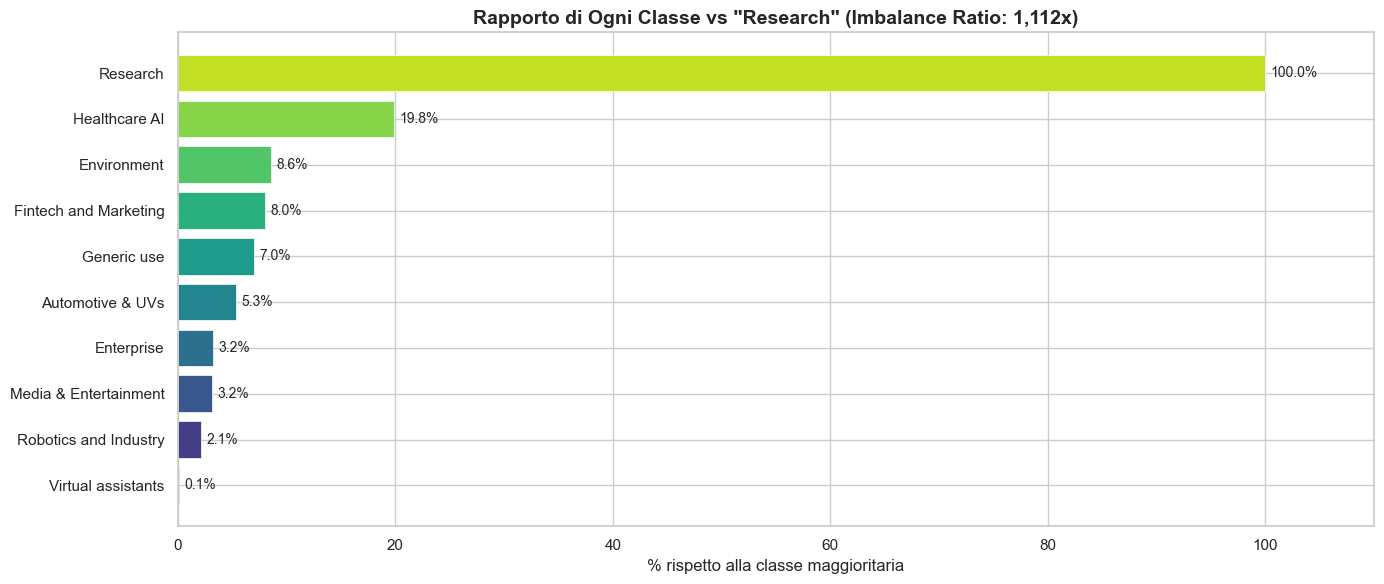

In [36]:
counts = df['Label'].value_counts()
max_class = counts.iloc[0]
min_class = counts.iloc[-1]

# Imbalance ratio
imbalance_ratio = max_class / min_class
print(f'Classe maggioritaria: {counts.index[0]} ({max_class:,})')
print(f'Classe minoritaria:   {counts.index[-1]} ({min_class:,})')
print(f'Imbalance Ratio:      {imbalance_ratio:,.1f}x')

# Entropia normalizzata della distribuzione
probs = counts.values / counts.values.sum()
entropy = -np.sum(probs * np.log2(probs))
max_entropy = np.log2(len(counts))
normalized_entropy = entropy / max_entropy
print(f'\nEntropia:             {entropy:.3f} bit')
print(f'Entropia max (uniforme): {max_entropy:.3f} bit')
print(f'Entropia normalizzata:   {normalized_entropy:.3f} (1.0 = perfettamente bilanciato)')

# Bar chart: rapporto di ogni classe rispetto alla maggioritaria
fig, ax = plt.subplots(figsize=(14, 6))
ratios = (counts / max_class * 100).sort_values(ascending=True)
colors = sns.color_palette('viridis', len(ratios))

bars = ax.barh(ratios.index, ratios.values, color=colors, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, ratios.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)

ax.set_xlabel('% rispetto alla classe maggioritaria')
ax.set_title(f'Rapporto di Ogni Classe vs "{counts.index[0]}" (Imbalance Ratio: {imbalance_ratio:,.0f}x)',
             fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 7. Bilanciamento con Subsampling

Parametro configurabile `SAMPLES_PER_CLASS`:
- Ogni classe viene sotto-campionata a `SAMPLES_PER_CLASS` record
- Le classi con meno record di `SAMPLES_PER_CLASS` vengono mantenute intatte (nessun sovracampionamento)

In [37]:
# ===== PARAMETRO CONFIGURABILE =====
SAMPLES_PER_CLASS = 4000  # tetto massimo per classe (subsampling)
# ===================================

print(f'Target massimo per classe: {SAMPLES_PER_CLASS:,}')

sampled_dfs = []
for label, group in df.groupby('Label'):
    n = len(group)
    if n > SAMPLES_PER_CLASS:
        sampled = group.sample(n=SAMPLES_PER_CLASS, random_state=42)
        print(f'  {label}: {n:,} -> {SAMPLES_PER_CLASS:,} (sottocampionato)')
    else:
        sampled = group
        print(f'  {label}: {n:,} (invariato, sotto soglia)')
    sampled_dfs.append(sampled)

df_balanced = pd.concat(sampled_dfs, ignore_index=True)
df_balanced = df_balanced[['description', 'Label']]

print(f'\nDataset bilanciato: {df_balanced.shape}')
print(f'\nDistribuzione classi:')
print(df_balanced['Label'].value_counts())

Target massimo per classe: 4,000
  Automotive & UVs: 2,362 (invariato, sotto soglia)
  Enterprise: 1,435 (invariato, sotto soglia)
  Environment: 3,818 (invariato, sotto soglia)
  Fintech and Marketing: 3,566 (invariato, sotto soglia)
  Generic use: 3,115 (invariato, sotto soglia)
  Healthcare AI: 8,823 -> 4,000 (sottocampionato)
  Media & Entertainment: 1,404 (invariato, sotto soglia)
  Research: 44,475 -> 4,000 (sottocampionato)
  Robotics and Industry: 939 (invariato, sotto soglia)
  Virtual assistants: 40 (invariato, sotto soglia)

Dataset bilanciato: (24679, 2)

Distribuzione classi:
Label
Healthcare AI            4000
Research                 4000
Environment              3818
Fintech and Marketing    3566
Generic use              3115
Automotive & UVs         2362
Enterprise               1435
Media & Entertainment    1404
Robotics and Industry     939
Virtual assistants         40
Name: count, dtype: int64


,originale,dopo_subsampling,rimossi
Label,,,
Automotive & UVs,2362,2362,0
Enterprise,1435,1435,0
Environment,3818,3818,0
Fintech and Marketing,3566,3566,0
Generic use,3115,3115,0
Healthcare AI,8823,4000,4823
Media & Entertainment,1404,1404,0
Research,44475,4000,40475
Robotics and Industry,939,939,0


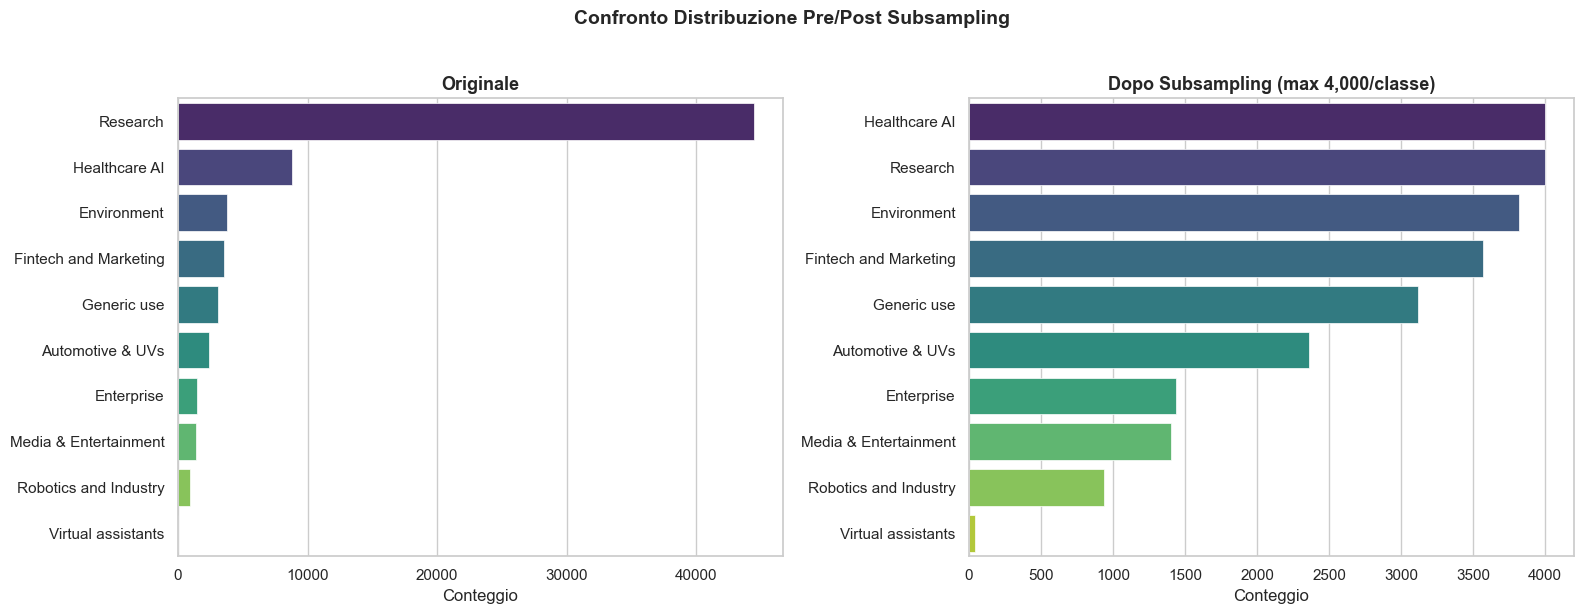

In [38]:
# Verifica post-bilanciamento
orig_counts = df['Label'].value_counts().sort_index()
bal_counts = df_balanced['Label'].value_counts().sort_index()

# Tabella riassuntiva
summary = pd.DataFrame({
    'originale': orig_counts,
    'dopo_subsampling': bal_counts,
    'rimossi': orig_counts - bal_counts,
})
display(summary)

# Grafico confronto
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, y='Label', order=label_order, palette='viridis',
              edgecolor='white', linewidth=0.5, ax=axes[0])
axes[0].set_title('Originale', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Conteggio')
axes[0].set_ylabel('')

bal_order = df_balanced['Label'].value_counts().index
sns.countplot(data=df_balanced, y='Label', order=bal_order,
              palette='viridis', edgecolor='white', linewidth=0.5, ax=axes[1])
axes[1].set_title(f'Dopo Subsampling (max {SAMPLES_PER_CLASS:,}/classe)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Conteggio')
axes[1].set_ylabel('')

plt.suptitle('Confronto Distribuzione Pre/Post Subsampling', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [39]:
# Salvataggio dataset bilanciato
out_path = DATA_DIR / 'pwc_distilled_balanced.csv'
df_balanced.to_csv(out_path, index=False)
print(f'Dataset bilanciato salvato in: {out_path}')
print(f'Righe: {len(df_balanced):,} | Classi: {df_balanced["Label"].nunique()}')

Dataset bilanciato salvato in: ../data/distilled/pwc_distilled_balanced.csv
Righe: 24,679 | Classi: 10


## 8. Riepilogo

**Findings principali:**
- Il dataset distillato contiene ~70K record con 10 classi
- Forte sbilanciamento: "Research" domina (~64%), "Virtual assistants" estremamente rara (~0.06%)
- Le classi sono distribuite in modo non uniforme tra i 7 file sorgente (segmentazione per dominio)
- Il dataset bilanciato è stato salvato con il subsampling configurabile

**Output:** `data/distilled/pwc_distilled_balanced.csv`